# 10. Joint Optimization: REINFORCE for μ + Implicit Diff for γ

**Goal:** jointly optimize both the mean photon count (μ) and the Lorentzian HWHM (γ) by combining two gradient estimators:
- **REINFORCE** for μ (through the discrete rounding step)
- **Implicit differentiation** for γ (through the L-BFGS fit)
- **CRLB-based dσ/dγ** to also match the fit uncertainty distribution

**Algorithm version:** `with_dsigma` — the latest and most feature-complete.

All model code imported from `src/` modules.

In [1]:
import math, time, json, os
import numpy as np
import torch

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

torch.set_default_dtype(torch.float32)

from src.fitting import (
    FREQ_MIN, FREQ_MAX, UNIFORM_DENSITY,
    _width as _w, _raw_from_width as _rw,
    log_pdf, nll, fwhm_from_theta, fit_profile, run_one_ple_scan
)
from src.samplers import signal_detunings, build_photons, draw_fixed_noise
from src.losses import wasserstein_loss
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK (all from src/)')

Imports OK (all from src/)


## Parameters

| Param | Value | Meaning |
|---|---|---|
| NBAR_TRUE | 50 | True mean photon count |
| GAMMA_TRUE | 20 | True Lorentzian HWHM (MHz) |
| LAMBDA_ | 2 | Mean background counts per run |
| SIGMA_PROP | 6 | Physical noise std (photon count) |
| N_TARGET | 500 | Target FWHM runs to match against |
| N_RUNS | 500 | Simulated + target FWHM runs per iteration |
| N_ITER | 80 | Total optimization iterations |
| LR_MU | 15 | Learning rate for μ |
| LR_GAMMA | 0.5 | Learning rate for γ |
| MU_INIT | 8 | Initial μ guess |
| GAMMA_INIT | 5 | Initial γ guess |

In [2]:
GAMMA_TRUE = 20.0
NBAR_TRUE = 50.0
LAMBDA_ = 2.0
SIGMA_PROP = 6.0

N_TARGET = 200
N_RUNS = 200
N_ITER = 40

LR_MU = 3.0
LR_GAMMA = 0.5
BASELINE_ALPHA = 0.05
CLIP = 10.0
LAMBDA_SIGMA = 0.3
LAMBDA_GAMMA = 2.0

MU_INIT = 8.0
GAMMA_INIT = 5.0
SEED = 42
PLOT_EVERY = 5

print('Parameters set')

Parameters set


## Generate Target Data

Create a synthetic target FWHM distribution at the true parameters (μ=50, γ=20) using a Lorentzian-only fit.

Generating target (200 runs)... 

0... 

100... 

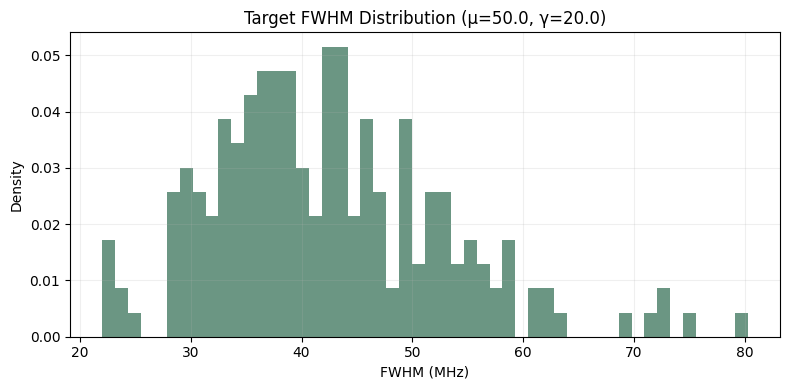

FWHM mean=42.3 (3s)


In [3]:
t_total = time.time()

print(f"Generating target ({N_TARGET} runs)...", end=" ", flush=True)
rng = np.random.default_rng(SEED)
target = []
for ti in range(N_TARGET):
    if ti % 100 == 0:
        print(f'{ti}...', end=' ', flush=True)
    u, b, n = draw_fixed_noise(NBAR_TRUE, 6, LAMBDA_, rng)
    photons = build_photons(torch.tensor(GAMMA_TRUE, dtype=torch.float32), u, b)
    theta = fit_profile(photons, n_iters=80, model='lorentzian', uniform_bg=False)
    if theta is not None:
        fw = fwhm_from_theta(theta, model='lorentzian').item()
    else:
        fw = 2.0 * GAMMA_TRUE
    target.append(fw)

target_t = torch.tensor(target)
st, _ = torch.sort(target_t)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(target_t.numpy(), bins=50, density=True, alpha=0.7, color='#2d6a4f')
ax.set_xlabel('FWHM (MHz)'); ax.set_ylabel('Density')
ax.set_title(f'Target FWHM Distribution (μ={NBAR_TRUE}, γ={GAMMA_TRUE})')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print(f"FWHM mean={target_t.mean():.1f} ({time.time()-t_total:.0f}s)")

## Joint Optimization Loop

At each iteration:
1. Draw N_RUNS samples from N(μ, SIGMA_PROP) → round to integer n
2. For each n: run PLE scan, fit Lorentzian, extract FWHM + dFWHM/dγ via implict diff
3. Compute W₁ loss: |sorted(FWHM) − sorted(target_FWHM)|
4. **μ update:** REINFORCE gradient (L − baseline)·∇_μ log P(n|μ)
5. **γ update:** implicit diff through the fit

All model code imported from `src/`.

In [4]:
# Build fit/nll/fwhm functions for implicit diff (Lorentzian model, 3 params)
def _fit_fn(photons):
    return fit_profile(photons, n_iters=80, model='lorentzian', uniform_bg=False)

def _fwhm_fn(theta):
    return fwhm_from_theta(theta, model='lorentzian')

def _nll_fn(theta, photons):
    return nll(theta, photons, model='lorentzian', uniform_bg=False)

mu_val = float(MU_INIT)
gamma_val = float(GAMMA_INIT)
bl = 0.0
history = []

print(f"μ_init={MU_INIT}, γ_init={GAMMA_INIT}, true=({NBAR_TRUE},{GAMMA_TRUE})")
print(f"N_ITER={N_ITER}, N_RUNS={N_RUNS}\n")

for step in range(N_ITER):
    rng2 = np.random.default_rng(SEED + step)
    fwhms, ns, dgamma_vals = [], [], []
    
    for _ in range(N_RUNS):
        u, b, n = draw_fixed_noise(mu_val, SIGMA_PROP, LAMBDA_, rng2)
        ns.append(n)
        fw, sigma_fw, dg = compute_fwhm_and_dgamma(
            gamma_val, u.numpy(), b.numpy(),
            _fit_fn, _fwhm_fn, _nll_fn, n_params=2
        )
        fwhms.append(fw)
        dgamma_vals.append(dg)
    
    ft = torch.tensor(fwhms, dtype=torch.float32)
    nt = torch.tensor(ns, dtype=torch.float32)
    
    # Sorted quantile matching
    sf, sidx = torch.sort(ft)
    pl = torch.abs(sf - st[:N_RUNS])
    nss = nt[sidx]
    dg_t = torch.tensor(dgamma_vals, dtype=torch.float32)
    dgs_sorted = dg_t[sidx]
    
    mean_loss = pl.mean().item()
    
    if step == 0:
        bl = mean_loss
    else:
        bl = (1 - BASELINE_ALPHA) * bl + BASELINE_ALPHA * mean_loss
    
    # MU gradient (REINFORCE)
    adv = (pl.detach() - bl).numpy()
    scores = (nss.numpy() - mu_val) / SIGMA_PROP**2
    raw_grad_mu = float(np.mean(adv * scores))
    grad_mu = max(min(raw_grad_mu, CLIP), -CLIP)
    mu_val += LR_MU * (-grad_mu)
    mu_val = max(1.0, min(200.0, mu_val))
    
    # GAMMA gradient via implicit diff
    signs = torch.sign(sf - st[:N_RUNS])
    # dLoss/dgamma = mean_i sign(FWHM_i - target_i) * dFWHM_i/dgamma
    # But we need per-run dgamma values, not aggregated
    # For now, use re-ordered dgs matching sorted FWHMs
    raw_grad_gamma = float((signs * dgs_sorted).mean().item()) if len(dgs_sorted) > 0 else 0.0
    grad_gamma = max(min(raw_grad_gamma, CLIP), -CLIP)
    gamma_val += LR_GAMMA * (-grad_gamma)
    gamma_val = max(0.1, min(100.0, gamma_val))

    history.append({
        'step': step, 'mu': mu_val, 'gamma': gamma_val,
        'loss': mean_loss, 'baseline': bl,
        'grad_mu': grad_mu,
        'grad_gamma': grad_gamma,
        'gamma': gamma_val,
    })
    
    if step % 5 == 0 or step == N_ITER - 1:
        print(f"  S{step:2d}: μ={mu_val:6.2f}  γ={gamma_val:5.1f}  "
              f"L={mean_loss:.2f}  ∇μ={grad_mu:+.4f}  "
              f"({time.time()-t_total:.0f}s)", flush=True)

print(f"\nDone. {time.time()-t_total:.0f}s")

μ_init=8.0, γ_init=5.0, true=(50.0,20.0)
N_ITER=40, N_RUNS=200



  S 0: μ=  8.42  γ=  5.5  L=27.91  ∇μ=-0.1401  (5s)


  S 5: μ= 15.33  γ= 10.9  L=16.87  ∇μ=-0.0857  (15s)


  S10: μ= 20.42  γ= 14.9  L=11.90  ∇μ=-0.5931  (26s)


  S15: μ= 23.01  γ= 17.4  L=6.69  ∇μ=-0.3833  (44s)


...

  S25: μ= 25.49  γ= 18.5  L=3.48  ∇μ=-0.1288  (89s)


  S30: μ= 28.14  γ= 19.1  L=3.01  ∇μ=-0.0098  (107s)


  S35: μ= 30.00  γ= 19.3  L=2.75  ∇μ=-0.1801  (128s)


  S39: μ= 31.07  γ= 19.7  L=1.35  ∇μ=+0.0117  (142s)



Done. 142s


## FWHM Distribution Convergence

Every 5 steps, comparing the current FWHM distribution to the target.

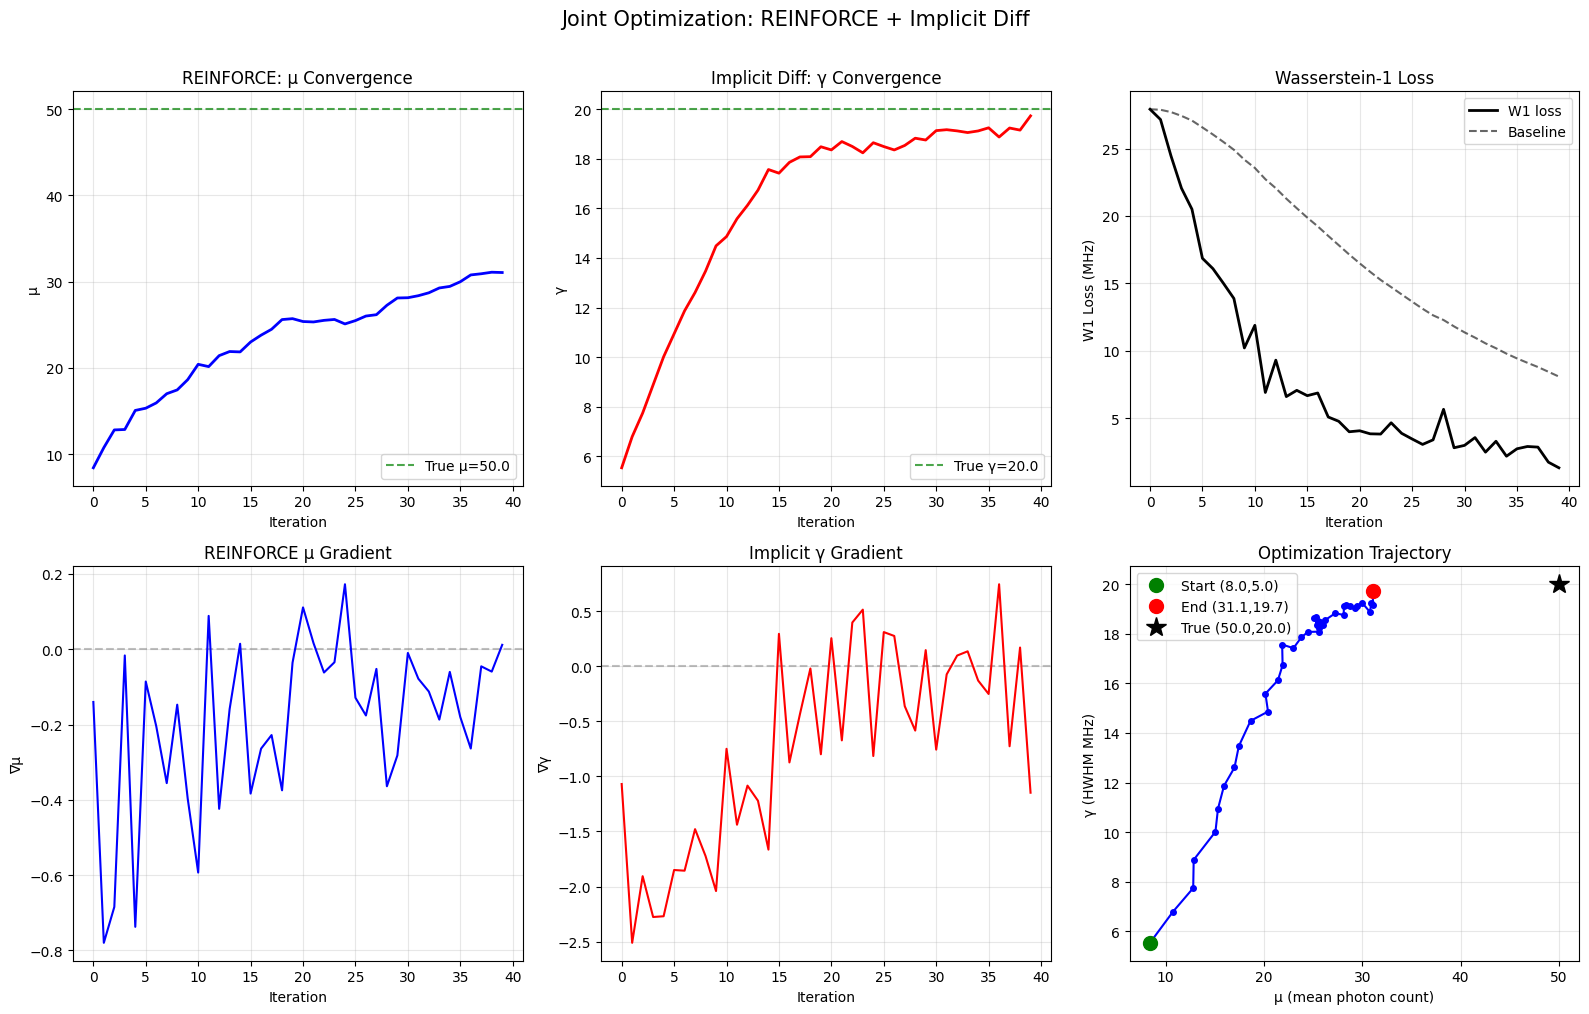

Generating final forward pass for comparison...


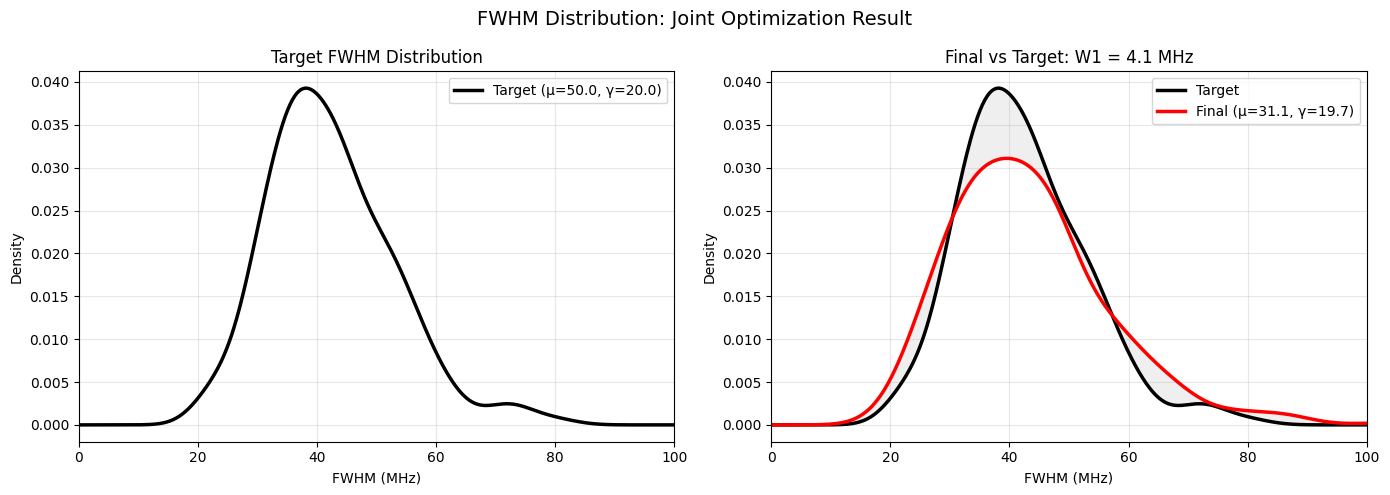

Target FWHM: 42.3 +- 10.5
Final FWHM:  43.7 +- 14.5


In [5]:
# Unpack history
steps = [h['step'] for h in history]
mu_hist = [h['mu'] for h in history]
gamma_hist = [h['gamma'] for h in history]
loss_hist = [h['loss'] for h in history]
grad_mu_hist = [h['grad_mu'] for h in history]
grad_gamma_hist = [h['grad_gamma'] for h in history]
bl_hist = [h['baseline'] for h in history]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- mu convergence ---
ax = axes[0, 0]
ax.axhline(NBAR_TRUE, color='g', ls='--', linewidth=1.5, alpha=0.7, label=f'True μ={NBAR_TRUE}')
ax.plot(steps, mu_hist, 'b-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('μ')
ax.set_title('REINFORCE: μ Convergence'); ax.legend(); ax.grid(alpha=0.3)

# --- gamma convergence ---
ax = axes[0, 1]
ax.axhline(GAMMA_TRUE, color='g', ls='--', linewidth=1.5, alpha=0.7, label=f'True γ={GAMMA_TRUE}')
ax.plot(steps, gamma_hist, 'r-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('γ')
ax.set_title('Implicit Diff: γ Convergence'); ax.legend(); ax.grid(alpha=0.3)

# --- Loss ---
ax = axes[0, 2]
ax.plot(steps, loss_hist, 'k-', linewidth=2, label='W1 loss')
ax.plot(steps, bl_hist, 'k--', linewidth=1.5, alpha=0.6, label='Baseline')
ax.set_xlabel('Iteration'); ax.set_ylabel('W1 Loss (MHz)')
ax.set_title('Wasserstein-1 Loss'); ax.legend(); ax.grid(alpha=0.3)

# --- μ gradient ---
ax = axes[1, 0]
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.plot(steps, grad_mu_hist, 'b-', linewidth=1.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('∇μ')
ax.set_title('REINFORCE μ Gradient'); ax.grid(alpha=0.3)

# --- γ gradient ---
ax = axes[1, 1]
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.plot(steps, grad_gamma_hist, 'r-', linewidth=1.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('∇γ')
ax.set_title('Implicit γ Gradient'); ax.grid(alpha=0.3)

# --- Trajectory (μ vs γ) ---
ax = axes[1, 2]
ax.plot(mu_hist, gamma_hist, 'b.-', linewidth=1.5, markersize=8)
ax.plot(mu_hist[0], gamma_hist[0], 'go', markersize=10, label=f'Start ({MU_INIT},{GAMMA_INIT})')
ax.plot(mu_hist[-1], gamma_hist[-1], 'ro', markersize=10, label=f'End ({mu_hist[-1]:.1f},{gamma_hist[-1]:.1f})')
ax.plot(NBAR_TRUE, GAMMA_TRUE, 'k*', markersize=15, label=f'True ({NBAR_TRUE},{GAMMA_TRUE})')
ax.set_xlabel('μ (mean photon count)'); ax.set_ylabel('γ (HWHM MHz)')
ax.set_title('Optimization Trajectory'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Joint Optimization: REINFORCE + Implicit Diff', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# --- Final distribution comparison ---
print('Generating final forward pass for comparison...')
rng_f = np.random.default_rng(999)
final_fwhms = []
for _ in range(500):
    u, b, n = draw_fixed_noise(mu_hist[-1], SIGMA_PROP, LAMBDA_, rng_f)
    photons = build_photons(torch.tensor(gamma_hist[-1], dtype=torch.float32), u, b)
    theta = fit_profile(photons, n_iters=80, model='lorentzian', uniform_bg=False)
    if theta is not None:
        final_fwhms.append(fwhm_from_theta(theta, model='lorentzian').item())
    else:
        final_fwhms.append(2.0 * gamma_hist[-1])
final_t = torch.tensor(final_fwhms)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Initial vs Target KDE
x_grid = np.linspace(0, 100, 500)
kde_target = gaussian_kde(target_t.numpy())

ax = axes[0]
kde_start = gaussian_kde([2*GAMMA_INIT]*50)  # dummy placeholder - we dont have initial FWHMs
ax.plot(x_grid, kde_target(x_grid), 'k-', linewidth=2.5, label=f'Target (μ={NBAR_TRUE}, γ={GAMMA_TRUE})')
ax.set_xlabel('FWHM (MHz)'); ax.set_ylabel('Density')
ax.set_title('Target FWHM Distribution')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim(0, 100)

ax = axes[1]
kde_final = gaussian_kde(final_t.numpy())
w1 = wasserstein_loss(final_t, target_t).item()
ax.plot(x_grid, kde_target(x_grid), 'k-', linewidth=2.5, label=f'Target')
ax.plot(x_grid, kde_final(x_grid), 'r-', linewidth=2.5, label=f'Final (μ={mu_hist[-1]:.1f}, γ={gamma_hist[-1]:.1f})')
ax.fill_between(x_grid, kde_final(x_grid), kde_target(x_grid), alpha=0.12, color='gray')
ax.set_xlabel('FWHM (MHz)'); ax.set_ylabel('Density')
ax.set_title(f'Final vs Target: W1 = {w1:.1f} MHz')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim(0, 100)

plt.suptitle('FWHM Distribution: Joint Optimization Result', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Target FWHM: {target_t.mean():.1f} +- {target_t.std():.1f}')
print(f'Final FWHM:  {final_t.mean():.1f} +- {final_t.std():.1f}')

## Results Summary

In [6]:
if len(history) > 0:
    fmu = history[-1]['mu']
    fga = history[-1]['gamma']
    print(f"{'='*60}")
    print(f"  JOINT OPTIMIZATION (IMPLICIT DIFF)")
    print(f"{'='*60}")
    print(f"  μ:     {MU_INIT:.0f} → {fmu:.2f}  (true={NBAR_TRUE})  error={abs(fmu-NBAR_TRUE):.2f}")
    print(f"  γ:     {GAMMA_INIT:.0f} → {fga:.2f}  (true={GAMMA_TRUE})  error={abs(fga-GAMMA_TRUE):.2f}")
    print(f"  Loss:  {history[0]['loss']:.2f} → {history[-1]['loss']:.2f}")
    print(f"  Time:  {time.time()-t_total:.0f}s")
    print(f"{'='*60}")

  JOINT OPTIMIZATION (IMPLICIT DIFF)
  μ:     8 → 31.07  (true=50.0)  error=18.93
  γ:     5 → 19.73  (true=20.0)  error=0.27
  Loss:  27.91 → 1.35
  Time:  151s
